# Homework 2

## Part A - Produce
### Python Code


In [54]:
import pandas as pd
import statsmodels.api as sm

df = pd.read_csv("roe01.txt", delim_whitespace=True)

# means
print(df.mean())

# correlation
print(df["ROEt"].corr(df["ROE"]))

# regression
X = sm.add_constant(df["ROEt"])
model = sm.OLS(df["ROE"], X).fit()

# explicitly print intercept and slope
print(model.params)

# or individually
print("Intercept =", model.params["const"])
print("Slope =", model.params["ROEt"])

ROEt       0.067778
ATO        0.429818
PM         0.210952
LEV        0.708852
GROWTH     0.331254
PB         2.126802
ARR        0.200780
INV        0.100044
ASSET     21.066002
ROE        0.410498
dtype: float64
0.5151321969256382
const    0.373844
ROEt     0.540797
dtype: float64
Intercept = 0.3738438723042008
Slope = 0.54079683224349


C:\Users\sromerod3\AppData\Local\Temp\ipykernel_47080\2179129240.py:4: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv("roe01.txt", delim_whitespace=True)


### R Code

In [55]:
# # Load data
# a <- read.table("roe01.txt", header = TRUE)

# # Calculations
# means <- colMeans(a)
# corr <- cor(a$ROEt, a$ROE)
# fit <- lm(ROE ~ ROEt, data = a)

# # Extract regression statistics
# intercept <- coef(fit)[1]
# slope <- coef(fit)[2]
# r_squared <- summary(fit)$r.squared

# # ===============================
# # SUMMARY OUTPUT
# # ===============================

# cat("\nCOLUMN MEANS\n")
# print(means)

# cat("\nCORRELATION BETWEEN ROEt AND ROE\n")
# print(corr)

# cat("\nLINEAR REGRESSION: ROE ~ ROEt\n")
# cat("Intercept =", intercept, "\n")
# cat("Slope =", slope, "\n")
# cat("R-squared =", r_squared, "\n")

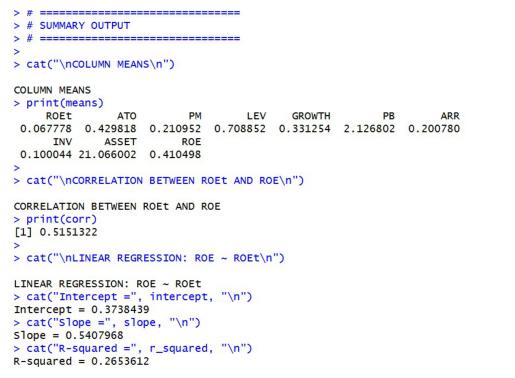

In [56]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(r"C:\Users\sromerod3\OneDrive\Documents\SEOUL 4803\R Code Part A HW 2.jpg")
plt.imshow(img)
plt.axis("off")
plt.show()

### Prompt for Claude
"(1) compute column means, a correlation, and a simple lm() linear fit in R; and (2) do the same computation in Python (numpy/statsmodels). Paste your prompts and both outputs." + attached the roe01.txt as a file

## Part B

In [57]:
# fit <- lm(ROE ~ ROEt, data = a)

# predict(fit, newdata = data.frame(ROEt = 0.3))

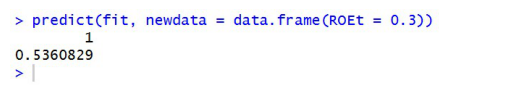

In [58]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(r"C:\Users\sromerod3\OneDrive\Documents\SEOUL 4803\r code part 2b.jpg")
plt.imshow(img)
plt.axis("off")
plt.show()

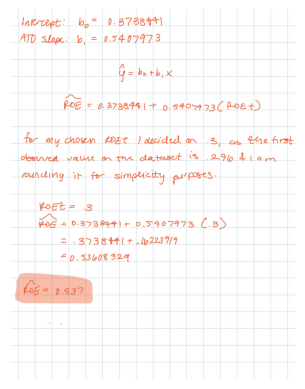

In [59]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(r"C:\Users\sromerod3\OneDrive\Documents\SEOUL 4803\HW 2 Part B.jpg")
plt.imshow(img)
plt.axis("off")
plt.show()

### Conclusion: 
The resultant predicted value using an ROEt (x) of 0.3 resulted in a Y value of ~0.537. The R code and my handheld calculation were off by 0.001, leading to conclude that the insignificant error/difference between the two can be due to rounding and computer computation power.

## Part C
### The Problematic Code


In [60]:
# returns <- read.csv("returns.csv") # columns: date, stockA, stockB
# returns$date <- as.factor(returns$date)
# avg <- mean(as.numeric(returns$stockA)) # "average of stock A"
# print(avg)

The issue is that returns$stockA is being treated by R as a factor instead of being a nujmber. This is the trap we discussed in class and more specifically on Slide 7. The issue is when it comes to reading the file, any small error within the data can lead to it being read as non-numeric. So in this code Line 3 isn't doing the intended purpose of averaging stock returns, but instead averaging the integer codes that R assigned each unique factor within the column. This is why the corrected includes the caveat on Line 2 to convert any possible column data into numeric.
### The Corrected Code

In [61]:
# returns <- read.csv("returns.csv", stringsAsFactors = FALSE)  # avoid the trap at the source
# returns$stockA <- as.numeric(as.character(returns$stockA))    # safe conversion
# avg <- mean(returns$stockA, na.rm = TRUE)                     # na.rm handles any real NAs
# print(avg)

## Part D
### 1. Default to Population vs. Sample Variance
R's var() and sd() always divides by n-1 (sample), but depending on the Python operation they default differently and can use population variance instead (n). NumPy's defaults to dividing by n, while Pandas doesn't have a an explicit divisor, but usually n-1. Overall, certain functions will use sample vairance and others will use population, ensuring that you are consistent amongst platforms.
### 2. How NA is handled
R usually will silently return NA or drop rows with it included if the function is not explicitly addressing NA functionality. Pandas, contrastly, auto-skips NaNs with 0 warning. This could lead to difference in row counts, and therefore coefficient, R^2, and correlation results. To address this issue, I propose to use judgement when interpreting the results. Whichever way it is calculated (dropped or calculated as 0) depending on the data policy/information youre trying to gather, you model it based on that functionality.
### 3. 0- vs -1 indexing
R indexes with 1, and Python indexes with 0 so any sliced arrays/columns being addressed can lead to different ones being called upon/pointed at. This could lead to incorrect variable usage.
